In [4]:
import pandas as pd
import os
from collections import Counter
import matplotlib.pyplot as plt
import numpy as np



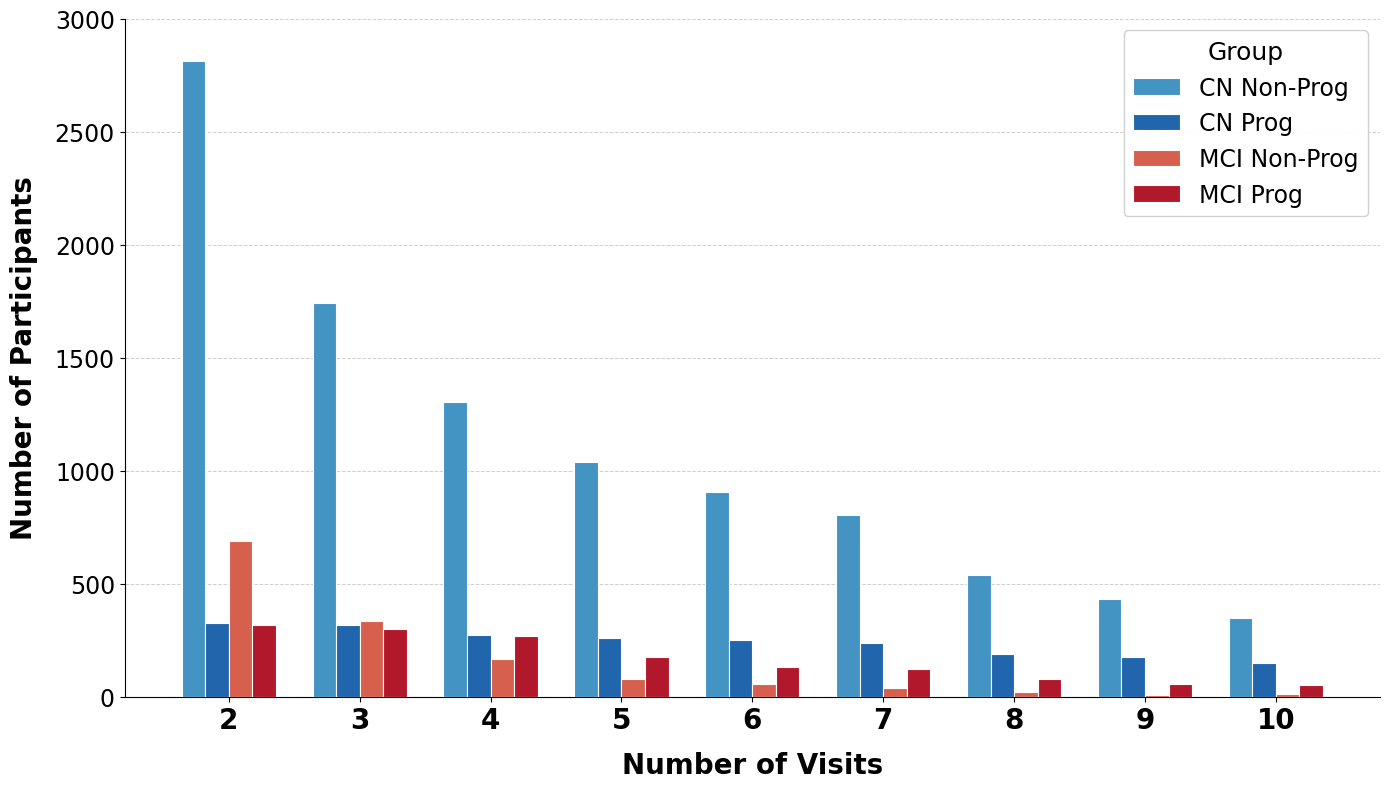

Saved → poster_group_barchart.png
           CN Non-Prog  CN Prog  MCI Non-Prog  MCI Prog
2 Visits          2810      324           689       316
3 Visits          1743      317           335       301
4 Visits          1304      272           165       266
5 Visits          1040      258            76       175
6 Visits           903      250            56       131
7 Visits           804      237            38       120
8 Visits           537      190            19        78
9 Visits           430      175             8        55
10 Visits          348      150            10        53


In [12]:
import ast

# ── Load data ──────────────────────────────────────────────────────────────────
cn_df  = pd.read_csv("datasets/Dataset_v2/pooled_CN.csv")
mci_df = pd.read_csv("datasets/Dataset_v2/pooled_MCI_AD.csv")

def parse_prog(s):
    return ast.literal_eval(s)

cn_df["prog_tuple"]  = cn_df["Progression"].apply(parse_prog)
mci_df["prog_tuple"] = mci_df["Progression"].apply(parse_prog)

cn_df["is_progressor"] = cn_df["prog_tuple"].apply(lambda t: any(x != 0 for x in t))
mci_df["is_progressor"] = mci_df["prog_tuple"].apply(lambda t: any(x == 2 for x in t))

cn_df["n_visits"]  = cn_df["prog_tuple"].apply(len)
mci_df["n_visits"] = mci_df["prog_tuple"].apply(len)

visit_counts = [2, 3, 4, 5,6,7,8,9,10]

groups = {
    "CN Non-Prog":  cn_df[~cn_df["is_progressor"]],
    "CN Prog":      cn_df[cn_df["is_progressor"]],
    "MCI Non-Prog": mci_df[~mci_df["is_progressor"]],
    "MCI Prog":     mci_df[mci_df["is_progressor"]],
}

counts = {
    label: [int((df["n_visits"] == v).sum()) for v in visit_counts]
    for label, df in groups.items()
}

colors = ["#4393C3", "#2166AC", "#D6604D", "#B2182B"]

fig, ax = plt.subplots(figsize=(14, 8))

n_groups = len(visit_counts)
n_bars   = len(groups)
bar_w    = 0.18
x        = np.arange(n_groups)

for i, (label, color) in enumerate(zip(groups.keys(), colors)):
    offsets = x + (i - (n_bars - 1) / 2) * bar_w
    bars = ax.bar(offsets, counts[label], bar_w,
                  label=label, color=color, edgecolor="white", linewidth=0.8, zorder=3)
    # for bar in bars:
    #     h = bar.get_height()
    #     if h > 0:
    #         ax.text(bar.get_x() + bar.get_width() / 2, h + 4,
    #                 str(int(h)), ha="center", va="bottom",
    #                 fontsize=10, fontweight="bold", color="#333333")

ax.set_xticks(x)
ax.set_xticklabels([f"{v}" for v in visit_counts], fontsize=20, fontweight="bold")
ax.set_ylabel("Number of Participants", fontsize=20, fontweight="bold", labelpad=12)
ax.set_xlabel("Number of Visits", fontsize=20, fontweight="bold", labelpad=12)

ax.set_ylim(0, 3000)
ax.set_yticks(range(0, 3001, 500))

ax.tick_params(axis="y", labelsize=17)
ax.grid(axis="y", linestyle="--", linewidth=0.7, alpha=0.6, zorder=0)
ax.set_axisbelow(True)
ax.spines[["top", "right"]].set_visible(False)

legend = ax.legend(
    title="Group", title_fontsize=18,
    fontsize=17, frameon=True, framealpha=0.9,
    edgecolor="#cccccc", loc="upper right"
)

plt.tight_layout()
plt.savefig("poster_group_barchart.png", dpi=300, bbox_inches="tight")
plt.show()
print("Saved → poster_group_barchart.png")

summary = pd.DataFrame(counts, index=[f"{v} Visits" for v in visit_counts])
print(summary)
